Environment Setup & Cloning

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Detected Google Colab. Bypassing dependency resolver...")

    !pip install timm
    !pip install git+https://github.com/IBM/terratorch.git

else:
    print("Running locally. Assuming repository is already downloaded.")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.append(os.path.abspath(os.getcwd()))

Detected Google Colab. Bypassing dependency resolver...
  Cloning https://github.com/IBM/terratorch.git to /tmp/pip-req-build-g4r3vz6o
  Running command git clone --filter=blob:none --quiet https://github.com/IBM/terratorch.git /tmp/pip-req-build-g4r3vz6o
  Resolved https://github.com/IBM/terratorch.git to commit d1267fbd278cd23bc05a1c22cc077e18481dd7c0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

Note: Please restart the Colab session before proceeding to avoid dependency conflicts.

In [1]:
print("\nCloning the official repository...")
!git clone https://github.com/karol140903/terramind-adversarial-robustness.git

%cd terramind-adversarial-robustness


Cloning the official repository...
Cloning into 'terramind-adversarial-robustness'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (146/146), done.
remote: Total 150 (delta 52), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 28.89 MiB | 11.02 MiB/s, done.
Resolving deltas: 100% (52/52), done.
/content/terramind-adversarial-robustness


Model Initialization

In [2]:
import torch
from terratorch import BACKBONE_REGISTRY

# Import core project modules
from src.attacks import pgd_cos, fgsm_cos
from src.metrics import compute_metrics
from src.visualization import plot_adversarial_comparison

# Import configuration and setup utilities
from src.utils import set_seed
from src.dataset import BANDS_ORDER

# Lock the environment for complete reproducibility before generating any attacks
set_seed(42)
print("Environment locked with fixed seed (42).")

# Initialize the model and move it to the appropriate device
print("Loading TerraMind base model...")
model = BACKBONE_REGISTRY.build("terramind_v1_base", pretrained=True, modalities=["S2L2A"])
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model successfully loaded on {device}.")

Environment locked with fixed seed (42).
Loading TerraMind base model...


TerraMind_v1_base.pt: reconstructing file:   0%|          |  0.00B / 1.52GB            

TerraMind_v1_base.pt: downloading bytes:           |  0.00B            

Model successfully loaded on cuda.


Data Loading, Adversarial Attack & Visualization

Loading 12-channel multispectral tensor from: data/patches/patch_04_city.pt
Executing PGD Attack (L_inf bound, Cosine similarity loss)...
Attack Results -> Cosine Similarity: 0.2353 | L2 Distance: 583.8167
Visualizing the physical adversarial noise in the RGB spectrum...


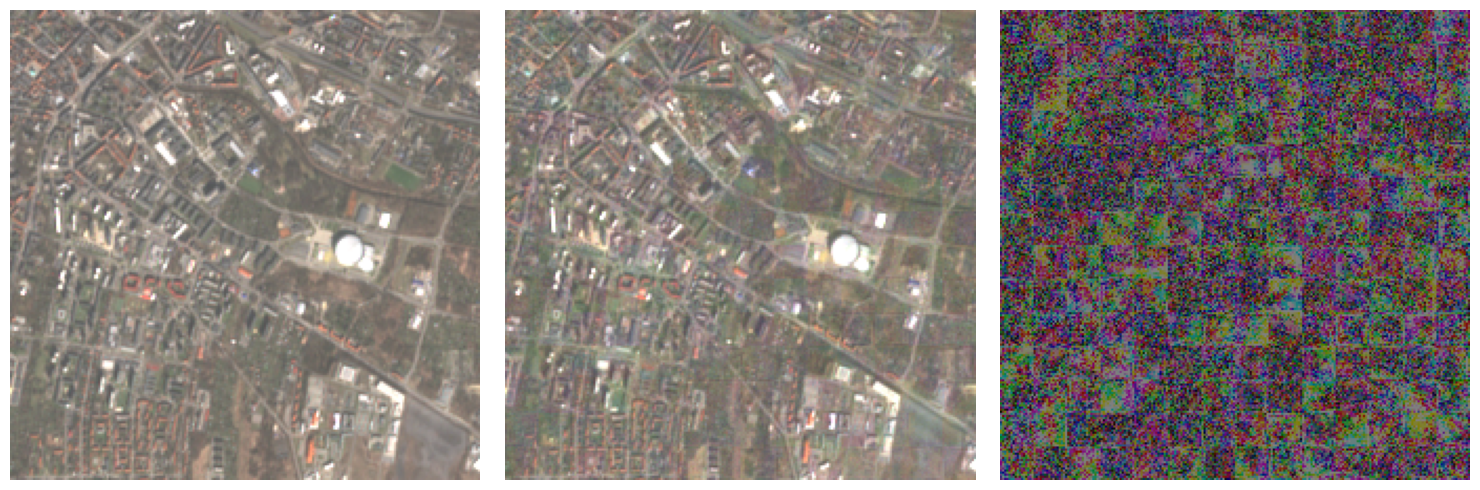

In [12]:
# Set seed to ensure reproducibility
set_seed(42)

# Define the path to the 12-channel PyTorch tensor
tensor_path = "data/patches/patch_04_city.pt"

print(f"Loading 12-channel multispectral tensor from: {tensor_path}")
x_orig = torch.load(tensor_path)
x_orig = x_orig.to(device)

print("Executing PGD Attack (L_inf bound, Cosine similarity loss)...")
# Generate the adversarial perturbation using the module function
x_adv_pgd = pgd_cos(model, x_orig, epsilon=0.01, alpha=0.002, steps=10)

# Evaluate the representation degradation in the high-dimensional latent space
cos_sim, l2_dist = compute_metrics(model, x_orig, x_adv_pgd)
print(f"Attack Results -> Cosine Similarity: {cos_sim:.4f} | L2 Distance: {l2_dist:.4f}")

print("Visualizing the physical adversarial noise in the RGB spectrum...")
# Plot the original, adversarial, and amplified difference maps
plot_adversarial_comparison(x_orig, x_adv_pgd, BANDS_ORDER)